In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# For maps
import geopandas as gpd
import contextily as cx

# For autocorrelation
from statsmodels.graphics.tsaplots import plot_acf

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [34]:
# Station-hour panel parquet 

import pandas as pd

DATA_PATH = Path("../outputs/ecobici_station_hour.parquet")

df = pd.read_parquet(DATA_PATH)

print(df.shape)
print(df["year"].unique())
print(df["departures"].describe().round(2))
print(df["arrivals"].describe().round(2))

(22463807, 14)
[2018 2019 2020 2021 2022 2023 2024 2025]
count    22463807.00
mean            3.61
std             4.37
min             0.00
25%             1.00
50%             2.00
75%             5.00
max           335.00
Name: departures, dtype: float64
count    22463807.00
mean            3.60
std             4.49
min             0.00
25%             1.00
50%             2.00
75%             5.00
max           344.00
Name: arrivals, dtype: float64


- The typical station has 2.0 departures and arrivals per hour.
- The distribution is right-skewed: 75% of hourly observations have 5 or fewer trips.
- The max reaches 335 departures and 344 arrivals; a small number of stations pull the mean (3.61) above the median (2.0)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22764830 entries, 0 to 22764829
Data columns (total 14 columns):
 #   Column           Dtype         
---  ------           -----         
 0   station_id       int64         
 1   datetime_hour    datetime64[us]
 2   departures       int64         
 3   arrivals         int64         
 4   net_flow         int64         
 5   abs_net_flow     int64         
 6   year             int64         
 7   month            int64         
 8   day              int64         
 9   hour             int64         
 10  weekday          int64         
 11  is_weekend       int32         
 12  is_morning_peak  int32         
 13  is_evening_peak  int32         
dtypes: datetime64[us](1), int32(3), int64(10)
memory usage: 2.1 GB


In [ ]:
df["departures"].sum(), 
df["arrivals"].sum()

(np.int64(81096021), np.int64(80839280))

In [ ]:
# Total yearly departures and arrivals

yearly = df.groupby("year")[["departures", "arrivals"]].sum().reset_index()
print(yearly)

   year  departures  arrivals
0  2018     8540225   8540225
1  2019     8415401   8415400
2  2020     4031867   4031867
3  2021     4295406   4295406
4  2022     4821097   4812019
5  2023    10379150  10306856
6  2024    21256801  21177644
7  2025    19356074  19259863


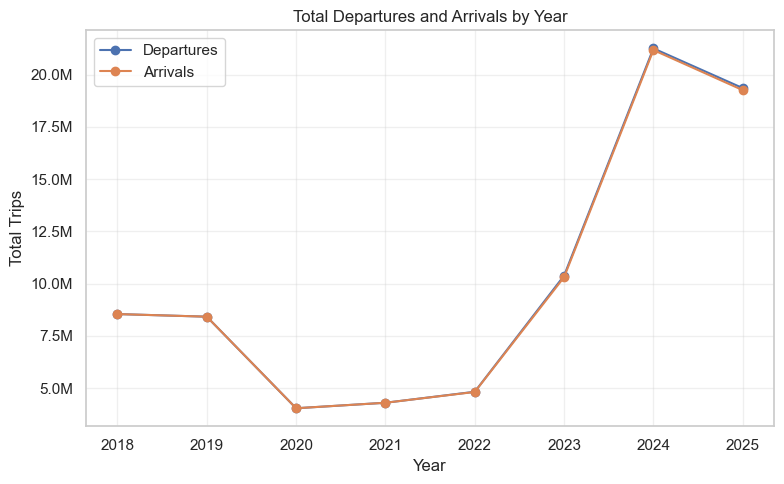

In [38]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(yearly["year"], yearly["departures"], marker="o", label="Departures")
ax.plot(yearly["year"], yearly["arrivals"], marker="o", label="Arrivals")

ax.set_title("Total Departures and Arrivals by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Total Trips")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [39]:
target = "departures"

X = df.drop(columns=[target, "datetime_hour"])
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (22463807, 12)
y shape: (22463807,)


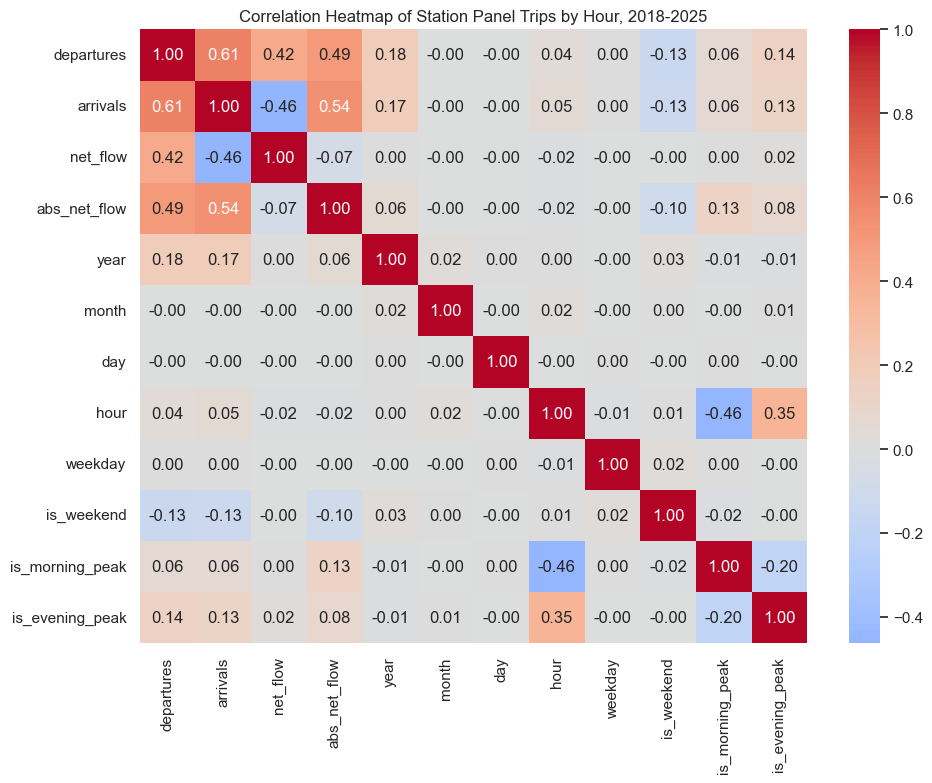

In [41]:
corr_cols = [
    "departures", "arrivals", "net_flow", "abs_net_flow",
    "year", "month", "day", "hour", "weekday",
    "is_weekend", "is_morning_peak", "is_evening_peak"
]

corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Station Panel Trips by Hour, 2018-2025")
plt.tight_layout()
plt.show()

# Strong relationships (worth noting):

- departures and arrivals (0.61) — stations where people take bikes also receive a lot, which means they are hubs
- arrivals and net_flow (-0.46) - stations with high arrivals have a negative net flow (more bikes coming, so a surplus)
- hour and is_morning_peak (-0.46) - morning peak takes place at specific times (e.g. 9 am), so other hours will not show a correlation as time progresses during the day
- hour and is_evening_peak (0.35) - evening peak has higher hour values, so as hour increases we get closer to the evening peak

# Other insights:
- month, day, and weekday correlate with almost nothing, meaning that trip volume by station doesn't vary beacause of these
- year and departures (0.18) - these have a slight growth over time, could be related to the BSS growth
- is_weekend and departures (-0.13) - these could help explain the negative trips on weekends (e.g. commuters)

<Axes: xlabel='hour'>

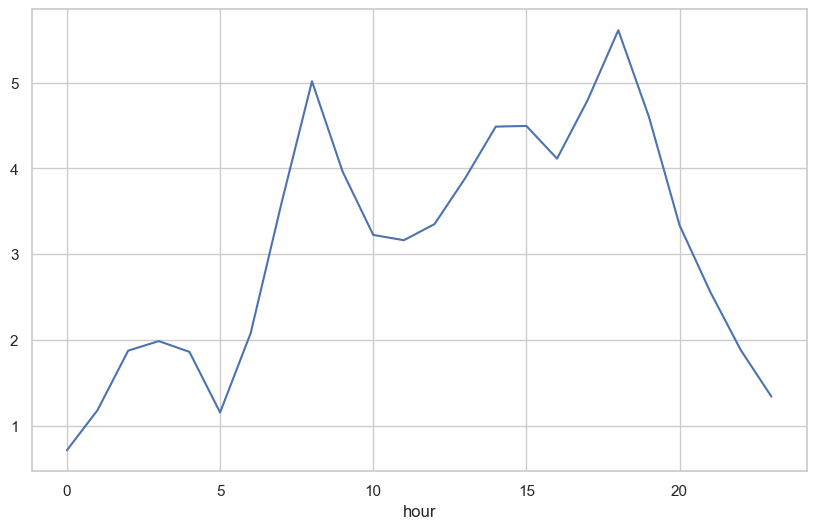

In [29]:
df.groupby("hour")["departures"].mean().plot()

<Axes: xlabel='hour'>

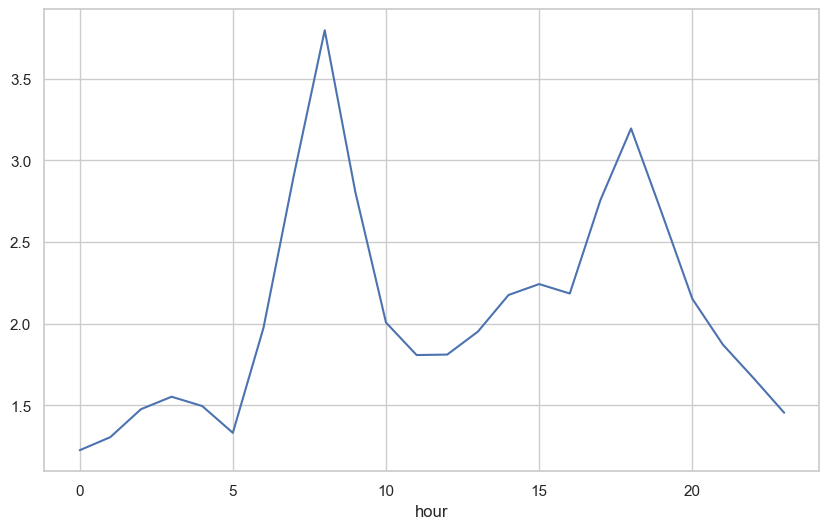

In [30]:
df.groupby("hour")["abs_net_flow"].mean().plot()